In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

sns.set(style="whitegrid")

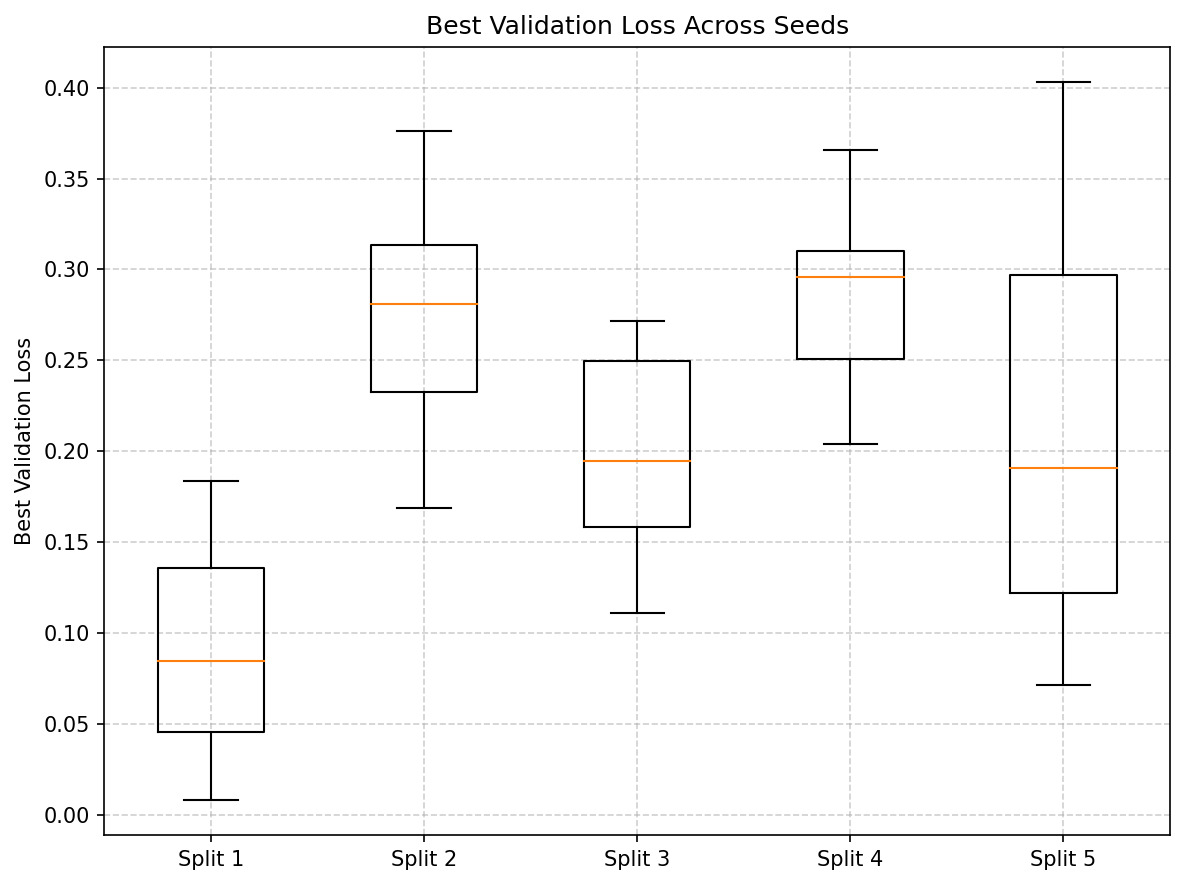

In [ ]:
import re
import matplotlib.pyplot as plt
import os

base_folder = "/projects/e32998/STAT390_Winter2026/Presentation4/STAT390_Winter2026_Team2/Code9_no_leakage/coders_task2/output_logs2"

splits = [1, 2, 3, 4, 5]
seeds = [8, 18, 24, 34, 49, 66, 68, 74, 93, 97]

pattern = re.compile(r"Best Val Loss:\s*([0-9\.]+)")

split_losses = []

for split in splits:

    losses = []

    for seed in seeds:

        results_file = os.path.join(
            base_folder,
            f"split{split}_seed{seed}",
            "results.txt"
        )

        if not os.path.exists(results_file):
            continue

        with open(results_file, "r") as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    losses.append(float(match.group(1)))
                    break

    split_losses.append(losses)


# =============================
# BOXPLOT
# =============================

plt.figure(figsize=(8,6), dpi=150)

plt.boxplot(split_losses)

plt.ylabel("Best Validation Loss")
plt.title("Best Validation Loss Across Seeds")
plt.xticks(range(1,6), [f"Split {i}" for i in splits])

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


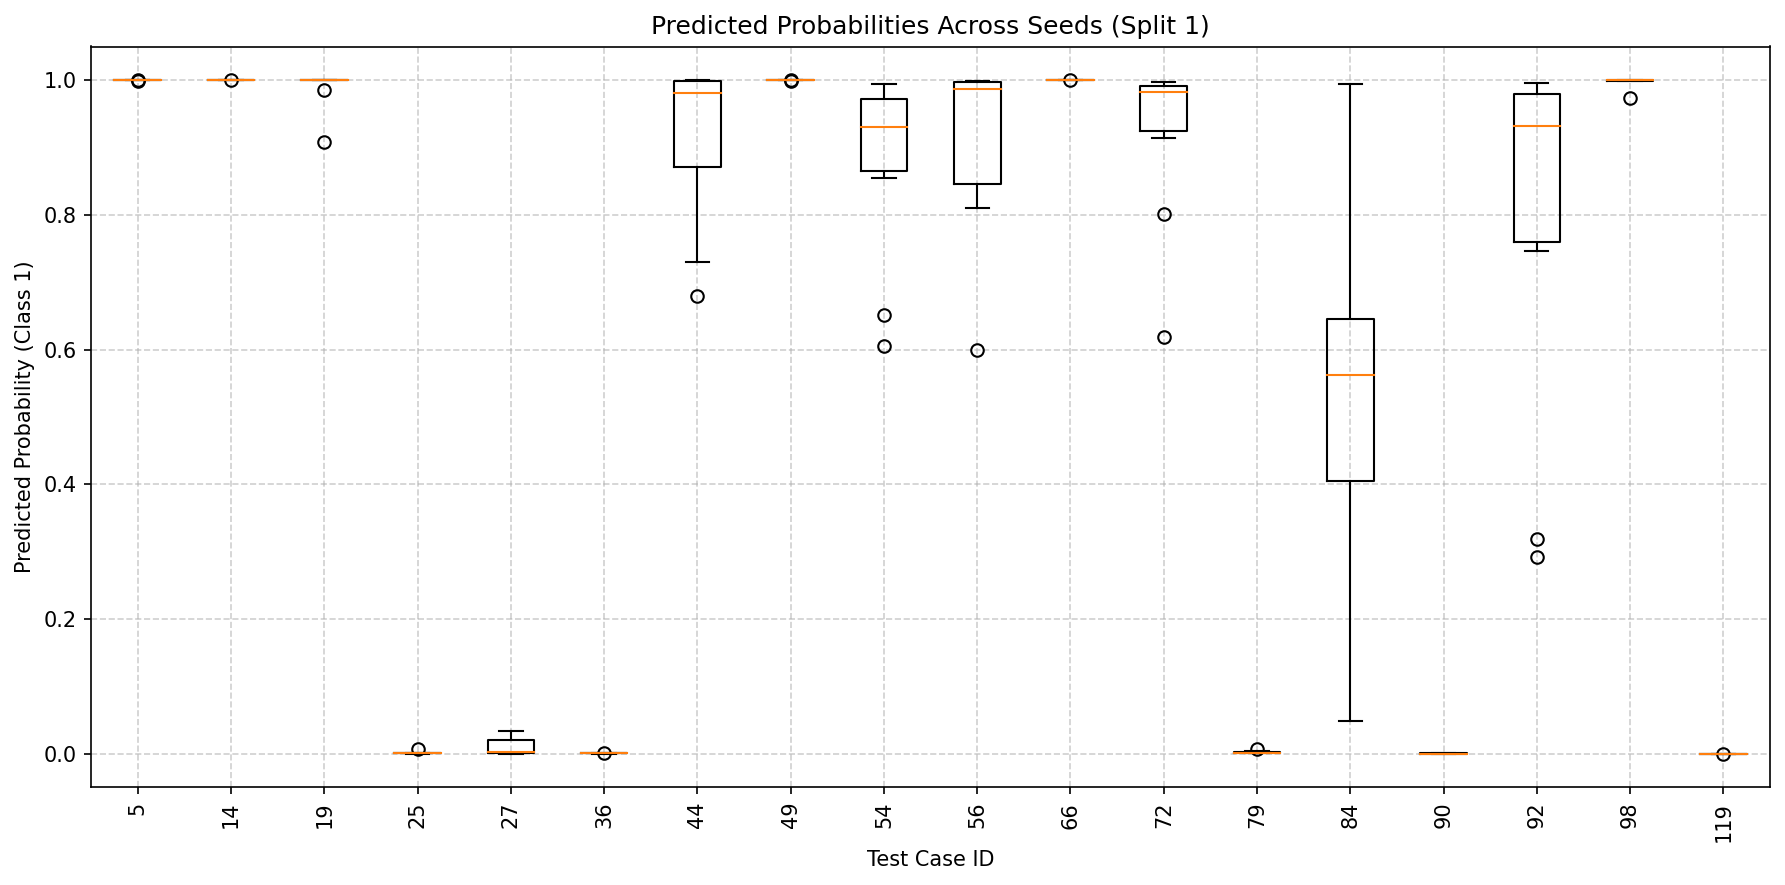

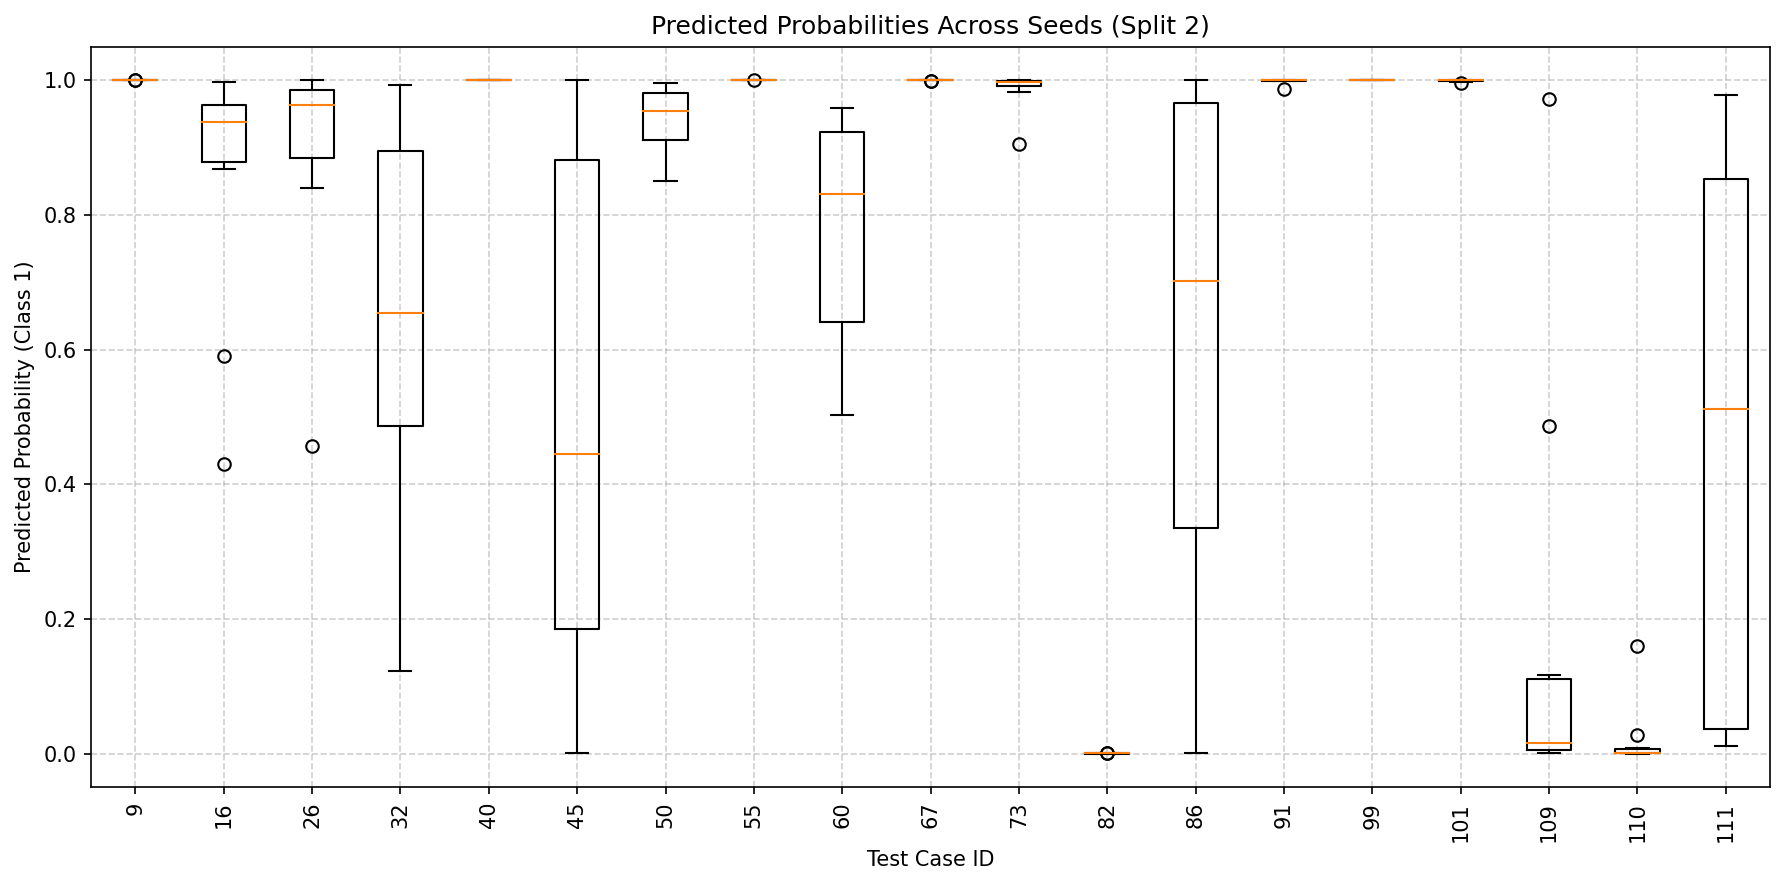

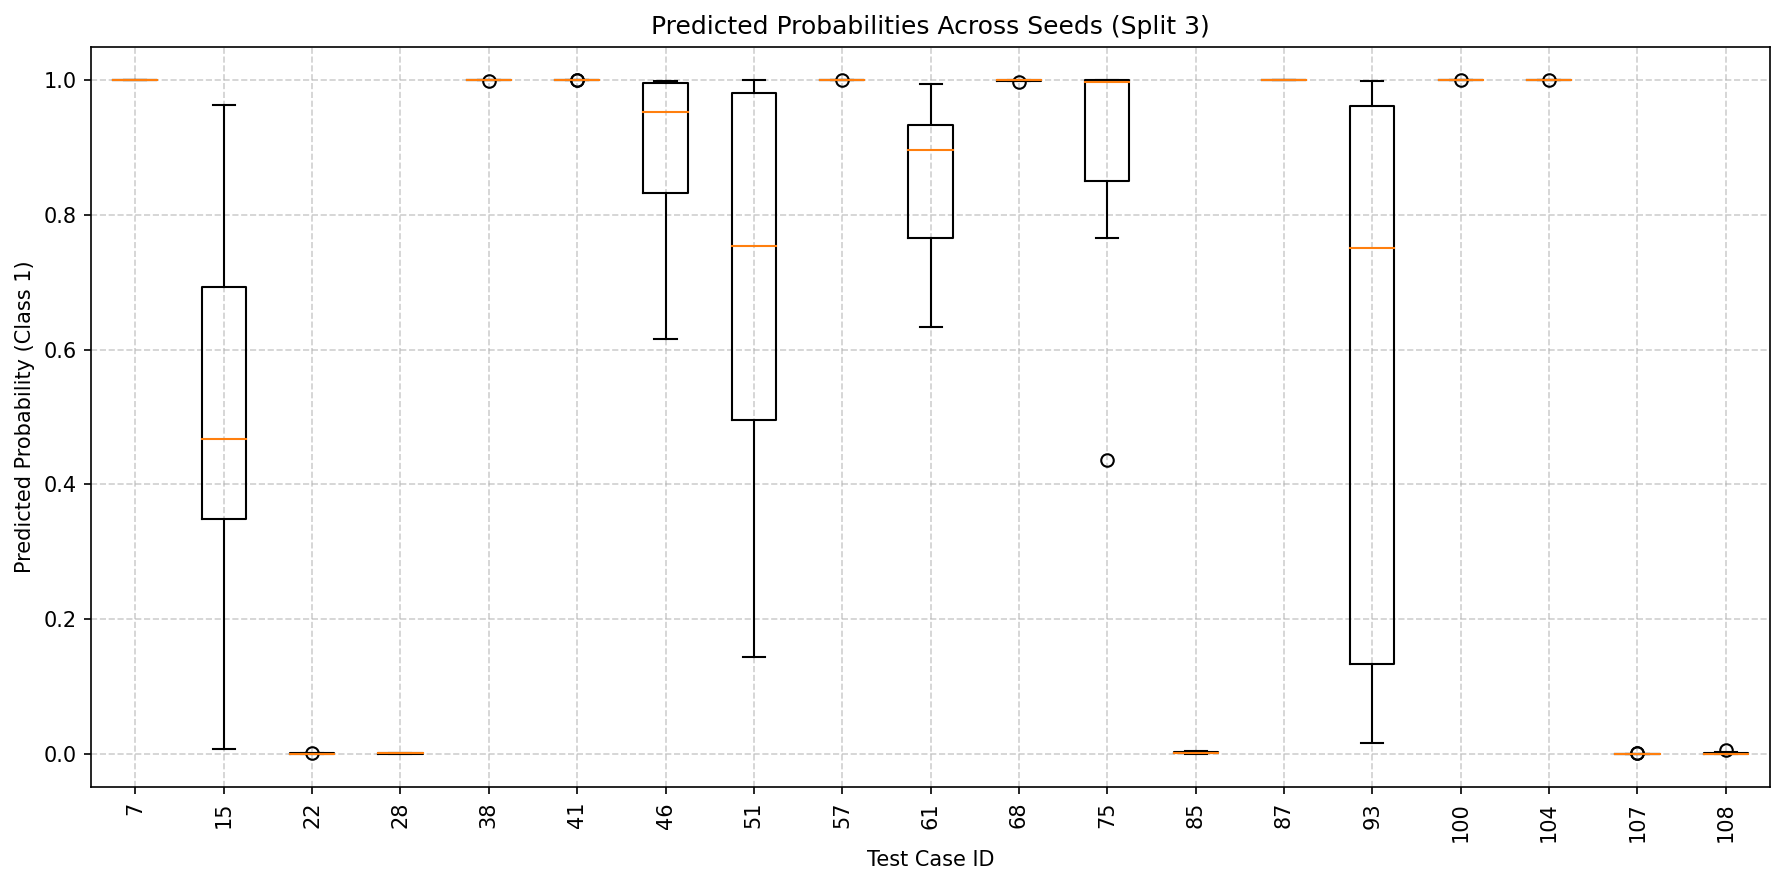

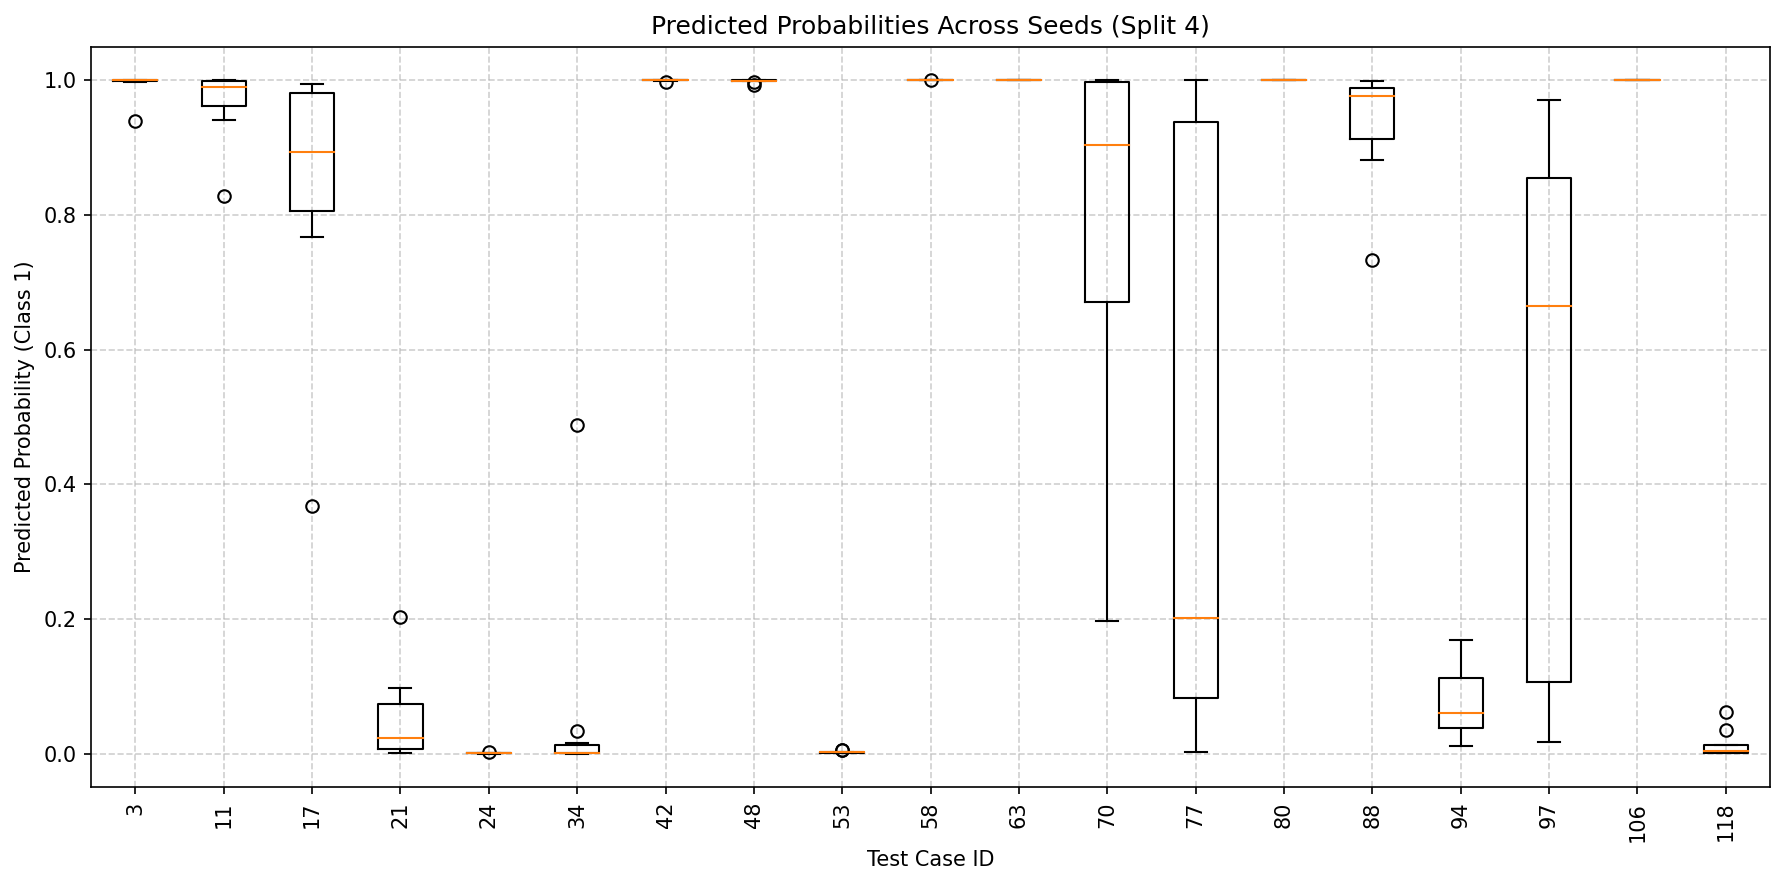

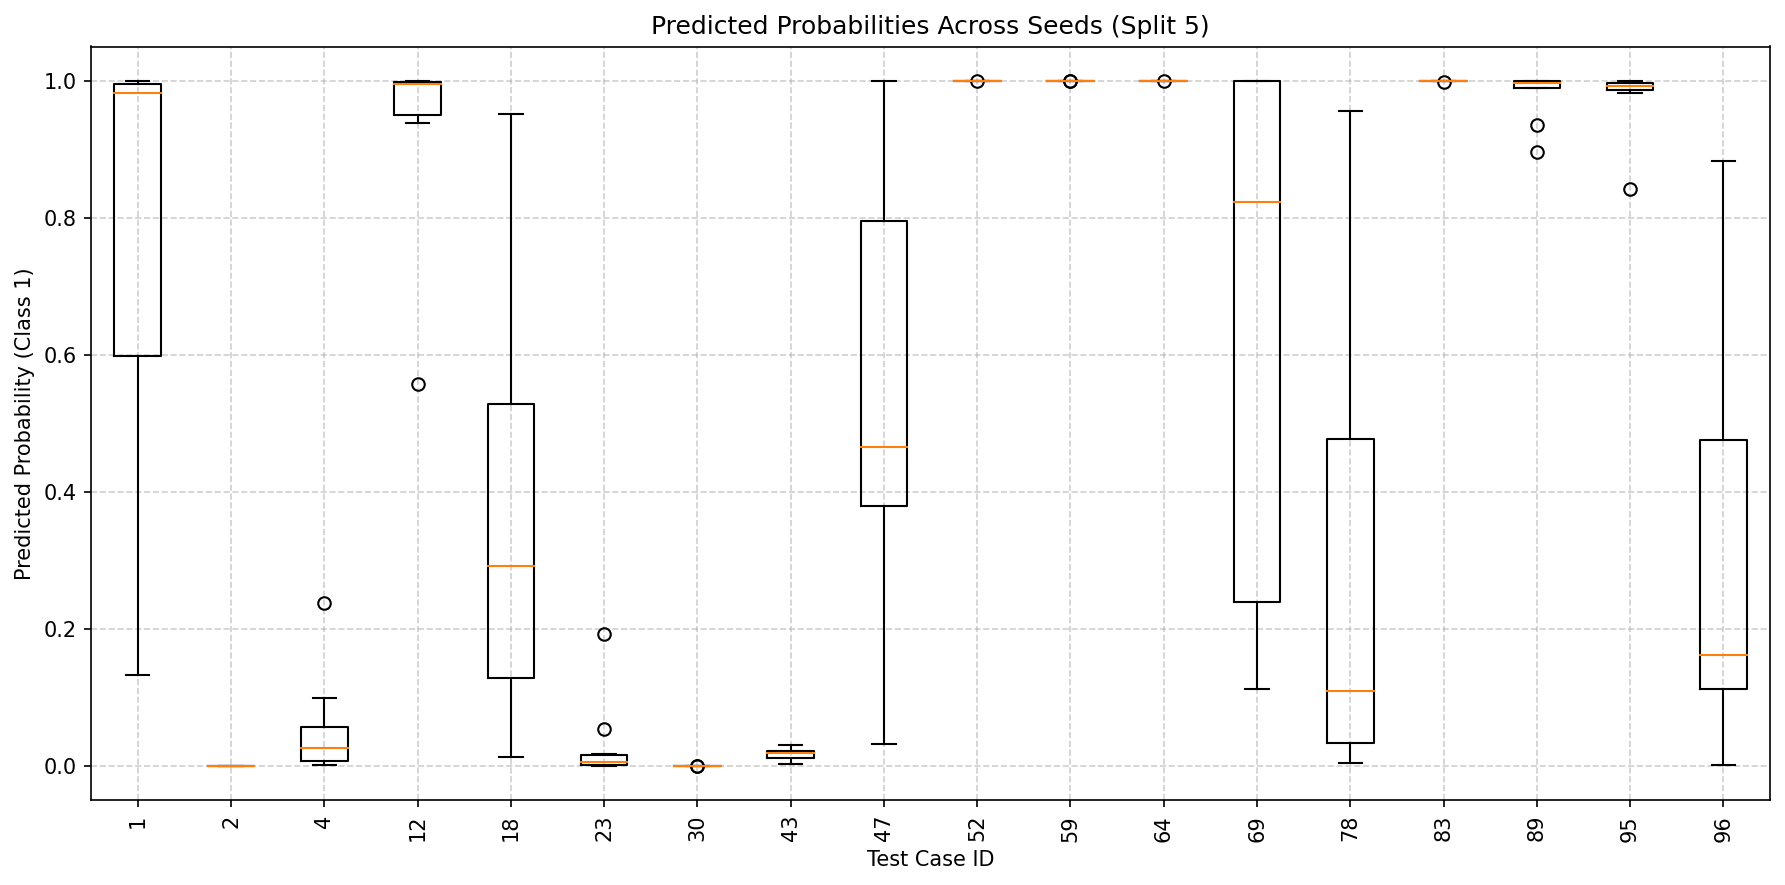

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

base_folder = "/projects/e32998/STAT390_Winter2026/Presentation4/STAT390_Winter2026_Team2/Code9_no_leakage/coders_task2/output_logs2"

splits = [1,2,3,4,5]
seeds = [8,18,24,34,49,66,68,74,93,97]   # add the 10th if needed

for split in splits:

    case_probs = {}

    # -------------------------
    # Load predictions for all seeds
    # -------------------------
    for seed in seeds:

        file_path = os.path.join(
            base_folder,
            f"split{split}_seed{seed}",
            "predictions.csv"
        )

        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        for _, row in df.iterrows():

            case_id = row["case_id"]
            prob = row["prob_class1"]

            if case_id not in case_probs:
                case_probs[case_id] = []

            case_probs[case_id].append(prob)

    # -------------------------
    # Prepare data for boxplot
    # -------------------------
    case_ids = sorted(case_probs.keys())
    data = [case_probs[c] for c in case_ids]

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(12,6), dpi=150)

    plt.boxplot(data)

    plt.xticks(range(1, len(case_ids)+1), case_ids, rotation=90)

    plt.ylabel("Predicted Probability (Class 1)")
    plt.xlabel("Test Case ID")
    plt.title(f"Predicted Probabilities Across Seeds (Split {split})")

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import os
from collections import defaultdict

base_folder = "/projects/e32998/STAT390_Winter2026/Presentation4/STAT390_Winter2026_Team2/Code9_no_leakage/coders_task2/output_logs2"

splits = [1,2,3,4,5]
seeds = [8,18,24,34,49,66,68,74,93,97]  # add the 10th if needed

# store counts
correct_counts = defaultdict(int)
total_counts = defaultdict(int)

for split in splits:
    for seed in seeds:

        file_path = os.path.join(
            base_folder,
            f"split{split}_seed{seed}",
            "predictions.csv"
        )

        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        for _, row in df.iterrows():

            case_id = row["case_id"]
            correct = row["correct"]

            total_counts[case_id] += 1

            if correct:
                correct_counts[case_id] += 1


# compute consistency %
consistency_results = []

for case_id in sorted(total_counts.keys()):

    pct = 100 * correct_counts[case_id] / total_counts[case_id]

    consistency_results.append({
        "case_id": case_id,
        "runs_in_test": total_counts[case_id],
        "correct_runs": correct_counts[case_id],
        "consistency_percent": pct
    })


results_df = pd.DataFrame(consistency_results)

print(results_df)

# optionally save
results_df.to_csv("classification_consistency.csv", index=False)


    case_id  runs_in_test  correct_runs  consistency_percent
0         1             9             7            77.777778
1         2             9             9           100.000000
2         3             9             9           100.000000
3         4             9             9           100.000000
4         5             9             9           100.000000
..      ...           ...           ...                  ...
88      109             9             8            88.888889
89      110             9             9           100.000000
90      111             9             4            44.444444
91      118             9             9           100.000000
92      119             9             9           100.000000

[93 rows x 4 columns]


In [ ]:
import os
import re
import pandas as pd

base_folder = "/projects/e32998/STAT390_Winter2026/Presentation4/STAT390_Winter2026_Team2/Code9_no_leakage/coders_task2/output_logs2"

splits = [1,2,3,4,5]
seeds = [8,18,24,34,49,66,68,74,93,97]

pattern = re.compile(r"Test Accuracy:\s*([0-9\.]+)")

results = []

for split in splits:

    seed_accuracies = []

    for seed in seeds:

        file_path = os.path.join(
            base_folder,
            f"split{split}_seed{seed}",
            "results.txt"
        )

        if not os.path.exists(file_path):
            continue

        with open(file_path, "r") as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    acc = float(match.group(1))
                    seed_accuracies.append((seed, acc))
                    break

    if len(seed_accuracies) > 0:

        df = pd.DataFrame(seed_accuracies, columns=["seed", "accuracy"])
        df = df.sort_values("accuracy").reset_index(drop=True)

        # min
        min_row = df.iloc[0]

        # max
        max_row = df.iloc[-1]

        # median
        median_row = df.iloc[len(df)//2]

        results.append({
            "split": split,

            "min_test_accuracy": min_row["accuracy"],
            "min_seed": int(min_row["seed"]),

            "median_test_accuracy": median_row["accuracy"],
            "median_seed": int(median_row["seed"]),

            "max_test_accuracy": max_row["accuracy"],
            "max_seed": int(max_row["seed"])
        })

results_df = pd.DataFrame(results)

print(results_df)

   split  min_test_accuracy  min_seed  median_test_accuracy  median_seed  \
0      1             0.8333        34                0.9444           24   
1      2             0.7895        24                0.8421           66   
2      3             0.7895        24                0.8947            8   
3      4             0.8421        24                0.9474           68   
4      5             0.7222        34                0.8889           66   

   max_test_accuracy  max_seed  
0             0.9444        93  
1             0.8947        49  
2             0.9474        68  
3             1.0000        74  
4             0.9444         8  
